<a href="https://colab.research.google.com/github/JoshM435/ACTCW2/blob/main/py/Q1_folder/ACT_CW2_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1: Pick a traditional - non neural network approach to your problem. For my dataset i have chosen to attempt a 'Contour analysis and Edge detection' approach to identify planes in the photos in the dataset.

I chose this approach as planes in top-down aerial images have unique and relatively consistent features and edges which can be utilised within a contour-analysis/edge-detection approach to analysing this dataset. Planes also often consist of well-defined edges, due to elongated shapes; e.g. wings and fuselage. Allowing for this approach to isolate the shapes and edges.

I picked this approach for plane detection as aeroplanes often have unique contours and shapes, even when at different orientations and and sizes, however the edge detection system i have made is heavily reliant on planes being white as a primary factor in detecting edges, with the use of greyscale style imaging and then binary based imaging being used to isolate high intensity pixels, which are often the whitest, being taken as the basis to then use for edge detection, this is shown to work when planes are white and have no shadows impacting them, while unfortunately often disregarding planes which have colour variation or shadows affecting their silouette.
This being said the presence of clouds in the images can also impact detection.



Python Dependencies:
These are the code libraries necessary for this notebook to run


In [ ]:
# Python Dependencies
import kagglehub
import os
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np
import random

This code's purpose is to access the kagglehub library and extract the Airbus dataset from it. This code was pulled from the Kaggle website, as a recommended method of accessing this Kaggle dataset within a python notebook.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("airbusgeo/airbus-aircrafts-sample-dataset")
images_path = '/root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/images/'
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3


With this code we are able to see the visible files within the Kaggle Airbus Airplane Detection Dataset. The main data being used will be the images section of the dataset, consisting of aerial images of airports and in turn aeroplanes.


In [ ]:
# List files in the downloaded dataset
files = os.listdir(path)
print("Files in dataset:", files)

Files in dataset: ['images', 'annotations.csv', 'LICENSE.txt', 'extras', 'README.md']


This will allow us to call the images dataset simply using 'plane_images' and applying an index to it. Where we can also take a specific image and focus on it for the edge detection and contour analysis process.

In [ ]:
dataset_path = '/root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/images/'
plane_images = sorted([f for f in os.listdir(dataset_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
First_image = plane_images[12]
Final_image_path = os.path.join(dataset_path,First_image)
plane = cv2.imread(Final_image_path)

The subsequent code showes how to access the dataset using the full pathway and then name of the image file. Also showing how to display the chosen image.

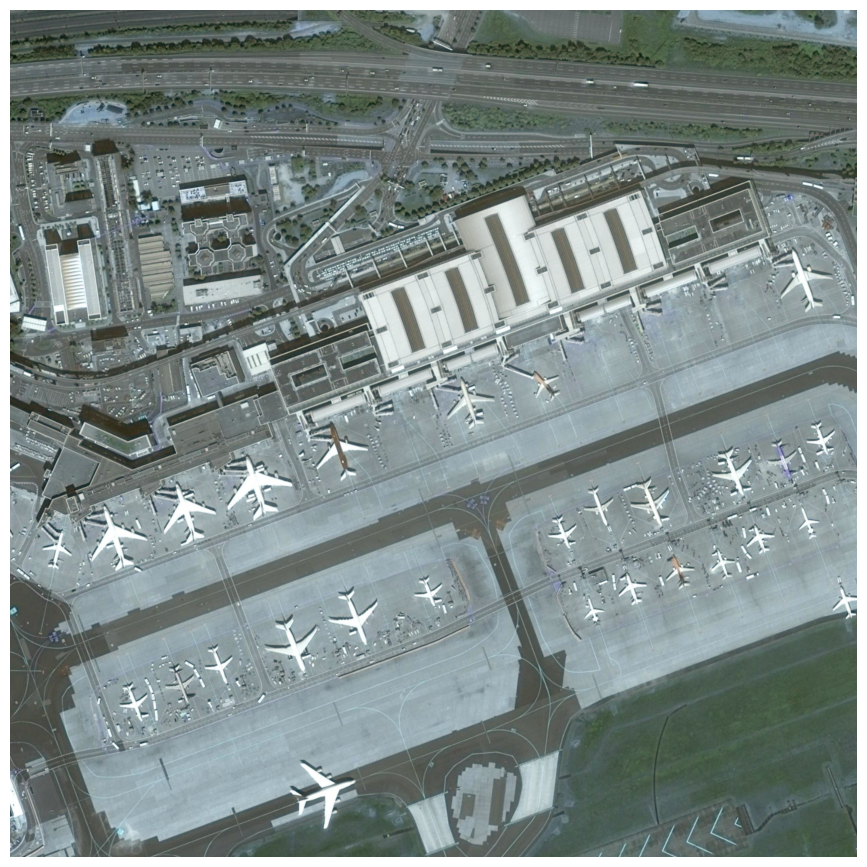

In [ ]:
images_path = cv2.imread('/root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/images/')

# Load an image
image = cv2.imread('/root/.cache/kagglehub/datasets/airbusgeo/airbus-aircrafts-sample-dataset/versions/3/images/014de911-7810-4f7d-8967-3e5402209f4a.jpg')

# Convert the image from BGR (OpenCV format) to RGB (for correct color display in matplotlib)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


# Display the image
plt.figure(figsize=(11, 11))
plt.imshow(plane)
plt.axis('off')

plt.show()

This code is an edge-detection and contour analysis process, which takes an image from the Kaggle dataset, attempting a set order of processes to attempt to detect edges and then apply contours to them, then appending the contours onto a copy of the original image.


1. Grayscale conversion code, this is aimed to format the image to a grascale format, allowing for the image to qualified on intensity of white rather than colour.
2. The Gaussian Blur code is intended to blur out the smaller non plane based intensity peaks, leaving just the plane edges to be idenified.
3. The binary code line converts the image to binary, with the aim of setting pixels with intensity above the second value within the bracket to white, whilst the rest are set to black.
4. The kernel code is intended to group contours that are in close proximity to one another, with the purpose of making potential contours of the same plane become one contoour and group into 1 contour value.
5. Edge Detection, applies the Canny Edge Detection algorithm to try and identify edges in the binary image, with thresholds for lower and upper edge gradients. Where those below the threshold are ignored.
6. Contour detection occurs with the for loop for contours, where cv2.RETR_EXTERNAL ignores nested contours and only takes the outermost contours as the true contour.
7. The contours are filtered based on their aspect ratio and area, with those lying outside the ranges being ignored.
8. The contours are then drawn onto the original image, allowing for accuracy testing, where the count of contours is calculated using len(filtered_contours).

This leads to an image within Contours drawn with the intention of finding the number of planes present. However this system relies on the fact that the majority of planes are white, for planes that have a different colour scheme it is likely this method won't work, buildings of white colour are also likely to be detected.






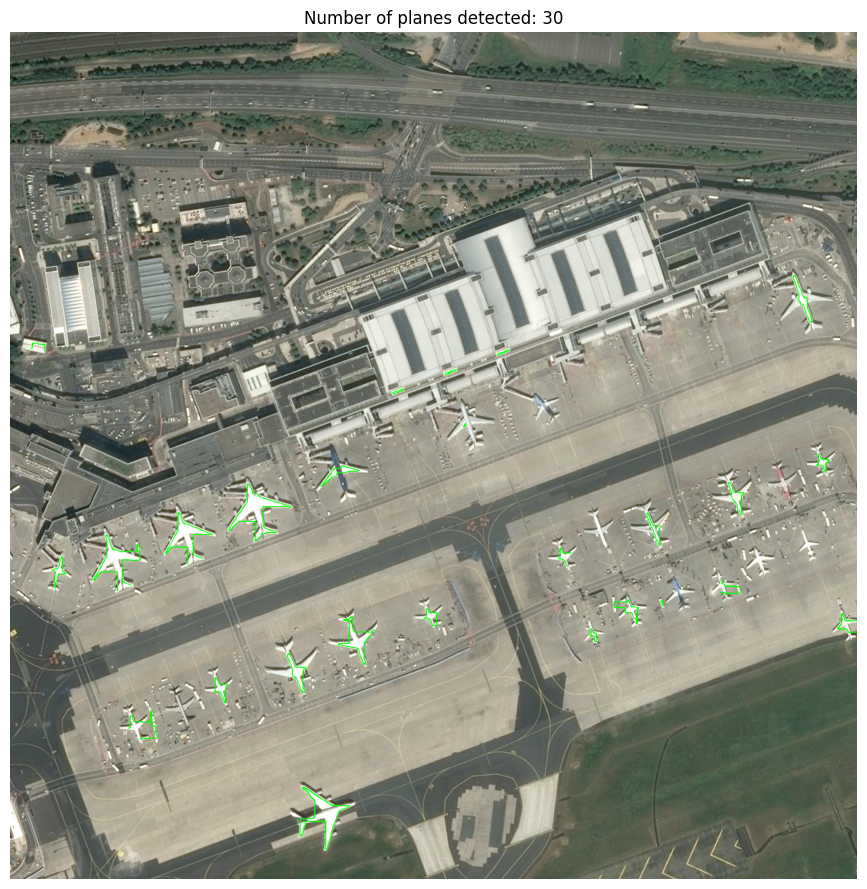

Number of planes detected: 30


In [ ]:
# Preprocess Image using cv2 commands
gray = cv2.cvtColor(plane, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 11), 0)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (50, 50))
_, binary = cv2.threshold(blurred, 250, 255, cv2.THRESH_BINARY)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
# Edge Detection using cv2 commands
edges = cv2.Canny(binary, threshold1=150, threshold2=210)

# Find Contours using cv2 commands
contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, 4)

# Filter Contours using cv2 commands
filtered_contours = []
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio = w / float(h)
    area = cv2.contourArea(contour)

    # Filter based on size and shape of planes
    if 0.4 < aspect_ratio < 6 and 10 < area < 15000 :
        filtered_contours.append(contour)

# Draw Contours with cv2 commands
output_image = plane.copy()
cv2.drawContours(output_image, filtered_contours, -1, (0, 255, 0), 2)
plane_count = len(filtered_contours)  # Count the filtered contours
# Display Output using cv2 and matplotlib.pyplot
output_image_rgb = cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)  # Convert to RGB for display
plt.figure(figsize=(11, 11))
plt.imshow(output_image_rgb)
plt.axis('off')
plt.title(f"Number of planes detected: {plane_count}")
plt.show()

print(f"Number of planes detected: {plane_count}")


This adaptation of this method factors in a parameter, being perimeter where contours that are not long enough are not considered when filtering. This is an attempt to remove the small contours caused by the buildings in the backgrounds, without impacting the contours of the planes. Aiming to improve accuracy of the number of planes.

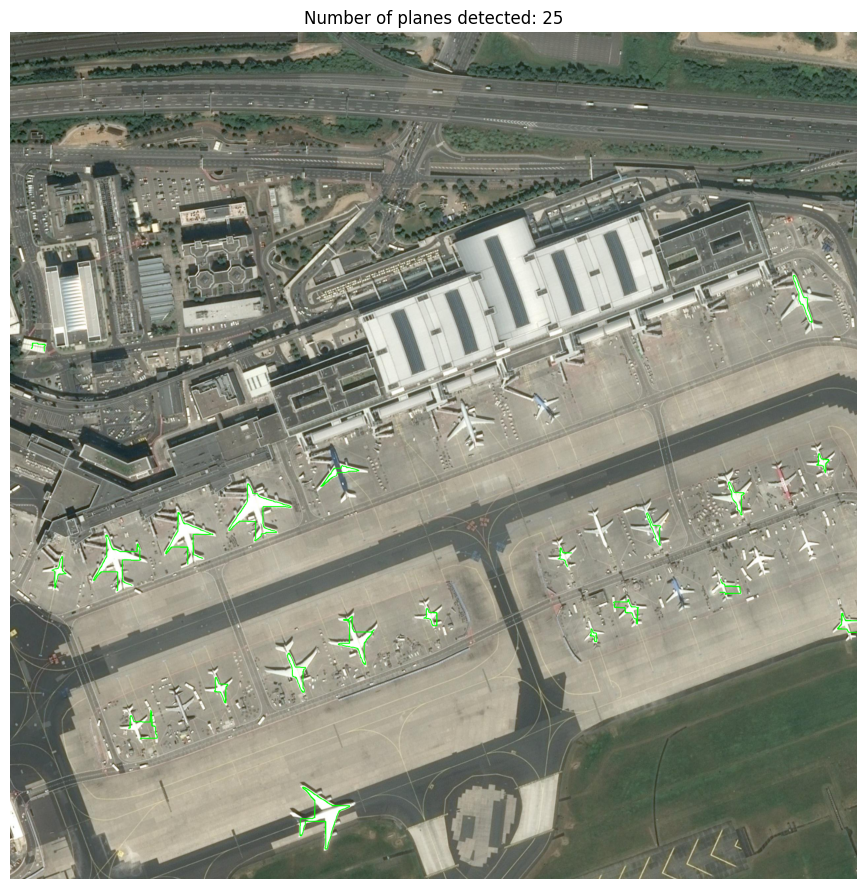

Number of planes detected: 25


In [ ]:
gray_1 = cv2.cvtColor(plane, cv2.COLOR_BGR2GRAY)
blurred_1 = cv2.GaussianBlur(gray_1, (5, 11), 0)
kernel_1 = cv2.getStructuringElement(cv2.MORPH_RECT, (50, 50))
_, binary_1 = cv2.threshold(blurred_1, 250, 255, cv2.THRESH_BINARY)
binary_1 = cv2.morphologyEx(binary_1, cv2.MORPH_CLOSE, kernel_1)

edges_1 = cv2.Canny(binary_1, threshold1=150, threshold2=210)

contours_1, _ = cv2.findContours(edges_1, cv2.RETR_EXTERNAL, 4)

filtered_contours_2 = []
for contour in contours_1:
    x, y, w, h = cv2.boundingRect(contour)
    aspect_ratio_2 = w / float(h)
    area_2 = cv2.contourArea(contour)
    perimeter_2 = cv2.arcLength(contour, True)



    # Combine filters
    if (
        10 < area_2 < 100000 and       # Filter by area
        0.2 < aspect_ratio_2 < 6 and    # Filter by aspect ratio
        perimeter_2 > 100           # Ensure minimum perimeter

    ):
        filtered_contours_2.append(contour)

# Draw and count planes
output_image_2 = plane.copy()
cv2.drawContours(output_image_2, filtered_contours_2, -1, (0, 255, 0), 2)
plane_count_2 = len(filtered_contours_2)

# Display results
output_image_rgb_2 = cv2.cvtColor(output_image_2, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(11, 11))
plt.imshow(output_image_rgb_2)
plt.axis("off")
plt.title(f"Number of planes detected: {plane_count_2}")
plt.show()
print(f"Number of planes detected: {plane_count_2}")


The code below runs the contour calculation process on each image respectively, showing the number of planes detected for each image. It then shows the image contouring process on a random image within the dataset. As shown previously this detection method isn't very accurate as shadows and colour variation negatively affect the edge detection process, whilst also considering white buildings of similar size as well.

To further improve this method you can pair it with template matching, to try and isolate the contours which resemble planes and disregard the contours which don't, this would solve the issue of buldings occuring in the contour detection.

Number of planes detected within image 1 {15}
Number of planes detected within image 2 {28}
Number of planes detected within image 3 {11}
Number of planes detected within image 4 {5}
Number of planes detected within image 5 {25}
Number of planes detected within image 6 {21}
Number of planes detected within image 7 {16}
Number of planes detected within image 8 {20}
Number of planes detected within image 9 {34}
Number of planes detected within image 10 {13}
Number of planes detected within image 11 {1}
Number of planes detected within image 12 {12}
Number of planes detected within image 13 {28}
Number of planes detected within image 14 {16}
Number of planes detected within image 15 {14}
Number of planes detected within image 16 {21}
Number of planes detected within image 17 {18}
Number of planes detected within image 18 {11}
Number of planes detected within image 19 {41}
Number of planes detected within image 20 {19}
Number of planes detected within image 21 {27}
Number of planes detecte

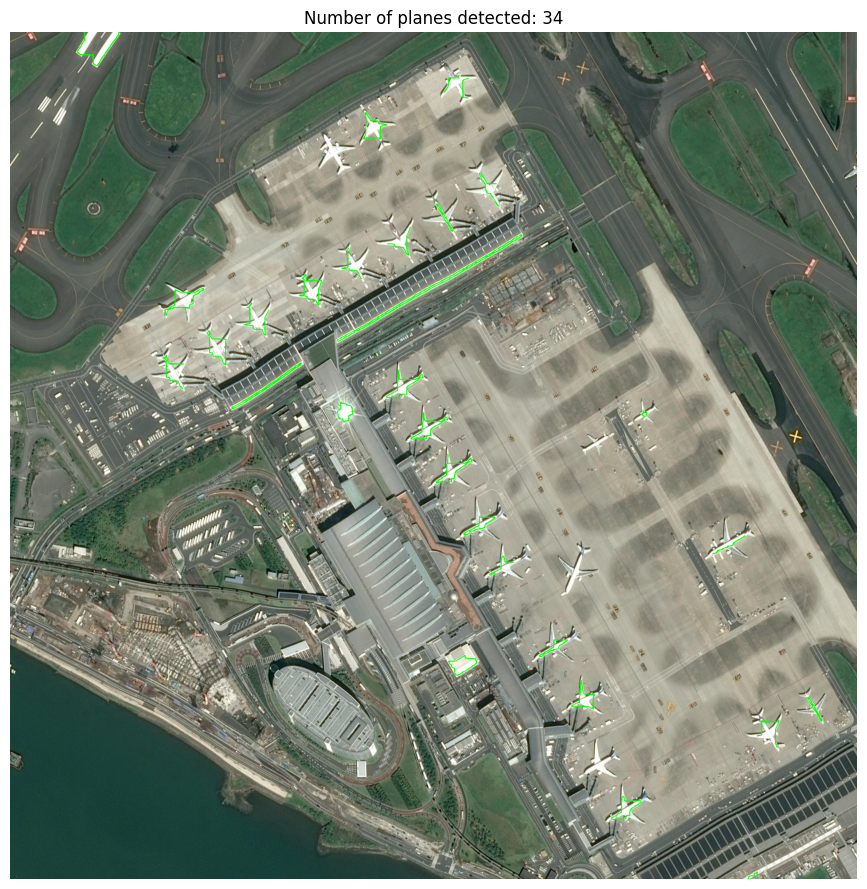

Number of planes detected: 34


In [ ]:

for i in range(len(plane_images)):

  Plane_Variation = cv2.imread(os.path.join(dataset_path, plane_images[i]))
  gray_V = cv2.cvtColor(Plane_Variation, cv2.COLOR_BGR2GRAY)
  blurred_V = cv2.GaussianBlur(gray_V, (5, 11), 0)
  kernel_V = cv2.getStructuringElement(cv2.MORPH_RECT, (45, 45))
  _, binary_V = cv2.threshold(blurred_V, 250, 255, cv2.THRESH_BINARY)
  binary_V = cv2.morphologyEx(binary_V, cv2.MORPH_CLOSE, kernel_V)
  edges_V = cv2.Canny(binary_V, threshold1=150, threshold2=210)
  contours_V, _ = cv2.findContours(edges_V, cv2.RETR_EXTERNAL, 4)
  filtered_contours_V = []

  for contour in contours_V:
      x, y, w, h = cv2.boundingRect(contour)
      aspect_ratio_V = w / float(h)
      area_V = cv2.contourArea(contour)
      perimeter_V = cv2.arcLength(contour, True)
      if 10 < area_V < 100000 and 0.2 < aspect_ratio_V < 6 and perimeter_V > 80:
          filtered_contours_V.append(contour)
  print(f"Number of planes detected within image",(i+1), {len(filtered_contours_V)})
Plane_Variation_R = cv2.imread(os.path.join(dataset_path, plane_images[random.randint(0,102)]))
gray_R = cv2.cvtColor(Plane_Variation_R, cv2.COLOR_BGR2GRAY)
blurred_R = cv2.GaussianBlur(gray_R, (5, 11), 0)
kernel_R = cv2.getStructuringElement(cv2.MORPH_RECT, (45, 45))
_, binary_R = cv2.threshold(blurred_R, 250, 255, cv2.THRESH_BINARY)
binary_R = cv2.morphologyEx(binary_R, cv2.MORPH_CLOSE, kernel_R)
edges_R = cv2.Canny(binary_R, threshold1=150, threshold2=210)
contours_R, _ = cv2.findContours(edges_R, cv2.RETR_EXTERNAL, 4)
filtered_contours_R = []
for contour in contours_R:
  x, y, w, h = cv2.boundingRect(contour)
  aspect_ratio_R = w / float(h)
  area_R = cv2.contourArea(contour)
  perimeter_R = cv2.arcLength(contour, True)
  if 10 < area_R < 100000 and 0.2 < aspect_ratio_R < 6 and perimeter_R > 75:
    filtered_contours_R.append(contour)
output_image_R = Plane_Variation_R.copy()
cv2.drawContours(output_image_R, filtered_contours_R, -1, (0, 255, 0), 2)
plane_count_R = len(filtered_contours_R)


output_image_rgb_R = cv2.cvtColor(output_image_R, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(11, 11))
plt.imshow(output_image_rgb_R)
plt.axis("off")
plt.title(f"Number of planes detected: {plane_count_R}")
plt.show()
print(f"Number of planes detected: {plane_count_R}")

The code within this notebook was adapted from Kaggle and ChatGPT
